# Capital Bikeshare Hourly Demand — Exploratory Data Analysis

**Course:** STAT 24620 / FINM 34700 / STAT 32950 — Spring 2026 Group Project

This notebook performs a detailed exploratory data analysis (EDA) on the
`bike_sharing_hourly.csv` dataset.

**Tentative research question.** *What drives hourly bike-rental demand
(`cnt`) in Washington D.C., and how do calendar, weather, and time-of-day
covariates interact to shape it?*

The notebook is organized in two parts.

**Part 1 — classical EDA**
1. Setup and data overview
2. Distribution of the target variable
3. Time series and long-term trend
4. Hour-of-day patterns
5. Weather effects
6. Calendar and categorical effects
7. Casual vs. registered riders
8. Correlation structure and multicollinearity
9. Skewness and transformation considerations
10. Class balance of `high_demand`

**Part 2 — multivariate-structure EDA**
11. Mutual information vs. Pearson correlation
12. Temporal dependence: STL decomposition and autocorrelation
13. Variance decomposition of `log(1+cnt)` via nested ANOVA
14. PCA on day-level 24-hour profiles
15. K-means clustering of daily profiles
16. Hierarchical clustering of daily profiles
17. Non-linear embedding via t-SNE
18. Hour × temperature interaction surface
19. Multivariate outliers via Mahalanobis distance
20. Summary and method recommendations


## 1. Setup and data overview

In [1]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'

FIGDIR = 'figures'
os.makedirs(FIGDIR, exist_ok=True)

def savefig(name):
    plt.savefig(os.path.join(FIGDIR, name + '.pdf'))
    plt.savefig(os.path.join(FIGDIR, name + '.png'))


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
df = pd.read_csv('bike_sharing_hourly.csv')
df['dteday'] = pd.to_datetime(df['dteday'])
print('Shape:', df.shape)
df.head()


Shape: (17379, 18)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,high_demand
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16,Low
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40,Low
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32,Low
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13,Low
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1,Low


In [3]:
info = pd.DataFrame({
    'dtype'    : df.dtypes.astype(str),
    'n_unique' : df.nunique(),
    'n_missing': df.isna().sum(),
})
info


,dtype,n_unique,n_missing
instant,int64,17379,0
dteday,datetime64[ns],731,0
season,int64,4,0
yr,int64,2,0
mnth,int64,12,0
hr,int64,24,0
holiday,int64,2,0
weekday,int64,7,0
workingday,int64,2,0
weathersit,int64,4,0


- 17 379 rows, 18 columns; no missing values.
- Note that the file actually contains $17{,}379 < 17{,}544 = 731\!\times\!24$
  rows, meaning **165 day-hours are missing from the table altogether**
  (these are zero-rental hours that were dropped upstream). When we
  build a day-level matrix in Part 2 we will pad those gaps with zero.
- Per UCI documentation, `temp`, `atemp`, `hum`, `windspeed` are
  normalized to the unit interval (divided by 41, 50, 100, 67
  respectively).


In [4]:
season_map  = {1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Fall'}
weather_map = {1: '1 Clear', 2: '2 Mist', 3: '3 Light rain/snow', 4: '4 Heavy rain/snow'}
weekday_map = {0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'}

df['season_lbl']  = df['season'].map(season_map)
df['weather_lbl'] = df['weathersit'].map(weather_map)
df['weekday_lbl'] = df['weekday'].map(weekday_map)
df['is_weekend']  = (df['weekday'].isin([0, 6])).astype(int)
df['year_lbl']    = df['yr'].map({0: 2011, 1: 2012})

df['temp_c']   = df['temp']     * 41
df['atemp_c']  = df['atemp']    * 50
df['hum_pct']  = df['hum']      * 100
df['wind_kmh'] = df['windspeed']* 67


In [5]:
df[['cnt','casual','registered','temp','atemp','hum','windspeed']].describe().round(3)


,cnt,casual,registered,temp,atemp,hum,windspeed
count,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000
mean,189.463,35.676,153.787,0.497,0.476,0.627,0.190
std,181.388,49.305,151.357,0.193,0.172,0.193,0.122
min,1.000,0.000,0.000,0.020,0.000,0.000,0.000
25%,40.000,4.000,34.000,0.340,0.333,0.480,0.104
50%,142.000,17.000,115.000,0.500,0.485,0.630,0.194
75%,281.000,48.000,220.000,0.660,0.621,0.780,0.254
max,977.000,367.000,886.000,1.000,1.000,1.000,0.851


Mean hourly demand is 189.5 with sd 181.4 — strong right skew.
`casual + registered = cnt` exactly, so the two components must not
enter as predictors of `cnt`. `temp` and `atemp` look near-identical
already.

## 2. Distribution of the target variable

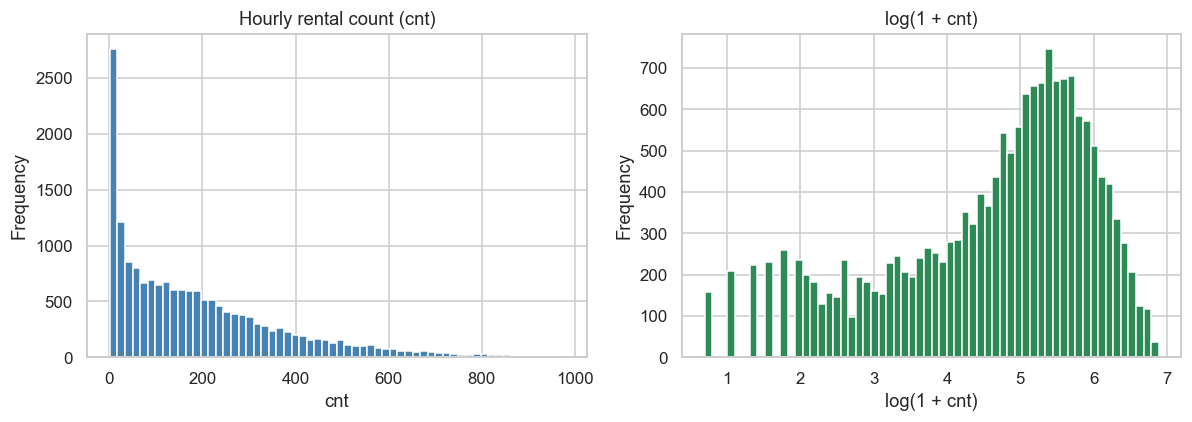

Skew of cnt        : 1.277
Kurt of cnt        : 1.416
Skew of log1p(cnt) : -0.818
Kurt of log1p(cnt) : -0.18


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df['cnt'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Hourly rental count (cnt)')
axes[0].set_xlabel('cnt'); axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['cnt']), bins=60, color='seagreen', edgecolor='white')
axes[1].set_title('log(1 + cnt)')
axes[1].set_xlabel('log(1 + cnt)'); axes[1].set_ylabel('Frequency')

plt.tight_layout()
savefig('fig01_cnt_distribution')
plt.show()

print('Skew of cnt        :', round(stats.skew(df['cnt']), 3))
print('Kurt of cnt        :', round(stats.kurtosis(df['cnt']), 3))
print('Skew of log1p(cnt) :', round(stats.skew(np.log1p(df['cnt'])), 3))
print('Kurt of log1p(cnt) :', round(stats.kurtosis(np.log1p(df['cnt'])), 3))


Raw `cnt` is strongly right-skewed (skewness ≈ 1.3). `log1p`
collapses the right tail and reveals a bimodal mixture — preview of
the commuter/leisure regimes we will discover in Part 2.

## 3. Time series and long-term trend

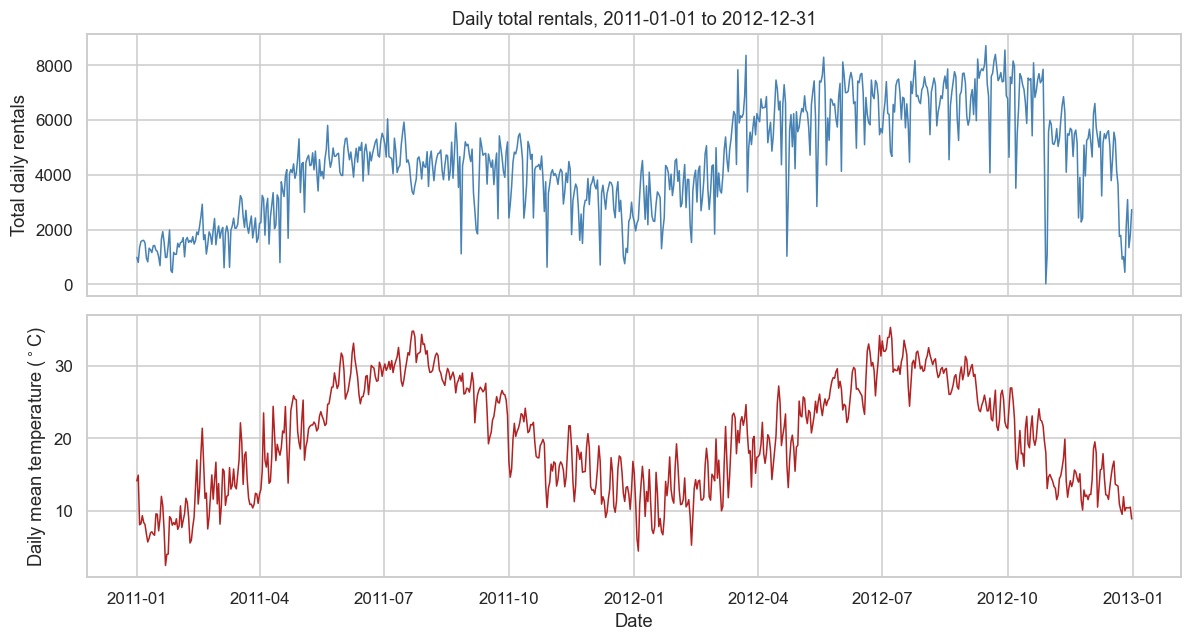

In [7]:
daily = df.groupby('dteday').agg(
    cnt=('cnt', 'sum'), casual=('casual', 'sum'),
    registered=('registered', 'sum'), temp_c=('temp_c','mean'),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(daily['dteday'], daily['cnt'], color='steelblue', lw=1)
axes[0].set_ylabel('Total daily rentals')
axes[0].set_title('Daily total rentals, 2011-01-01 to 2012-12-31')

axes[1].plot(daily['dteday'], daily['temp_c'], color='firebrick', lw=1)
axes[1].set_ylabel('Daily mean temperature ($^\circ$C)')
axes[1].set_xlabel('Date')
plt.tight_layout()
savefig('fig02_daily_timeseries')
plt.show()


Strong year-over-year growth + annual seasonal cycle tightly
correlated with temperature.

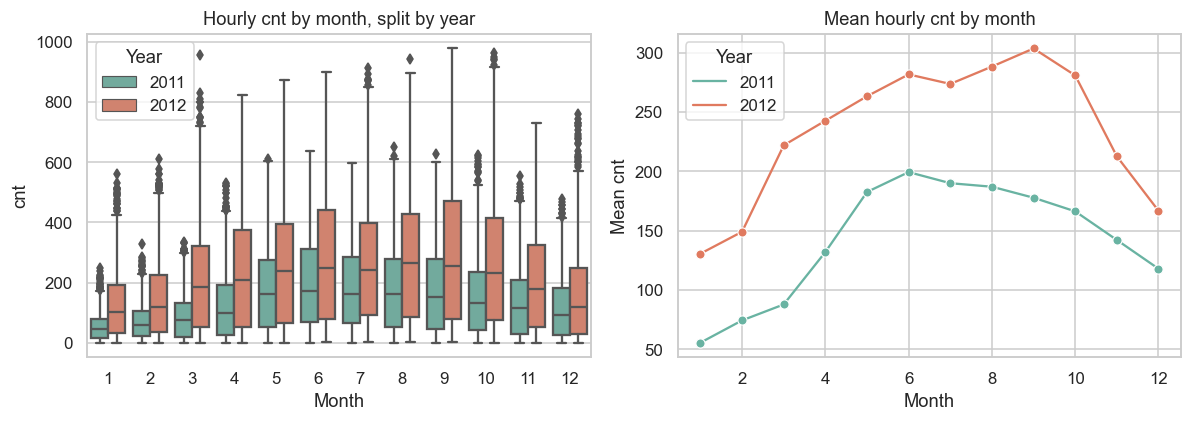

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=df, x='mnth', y='cnt', hue='year_lbl', ax=axes[0],
            palette=['#69b3a2', '#e07a5f'])
axes[0].set_title('Hourly cnt by month, split by year')
axes[0].set_xlabel('Month'); axes[0].set_ylabel('cnt')
axes[0].legend(title='Year')

monthly = df.groupby(['yr','mnth'])['cnt'].mean().reset_index()
monthly['year_lbl'] = monthly['yr'].map({0:2011, 1:2012})
sns.lineplot(data=monthly, x='mnth', y='cnt', hue='year_lbl', marker='o',
             ax=axes[1], palette=['#69b3a2', '#e07a5f'])
axes[1].set_title('Mean hourly cnt by month')
axes[1].set_xlabel('Month'); axes[1].set_ylabel('Mean cnt')
axes[1].legend(title='Year')
plt.tight_layout()
savefig('fig03_monthly_pattern')
plt.show()


## 4. Hour-of-day patterns

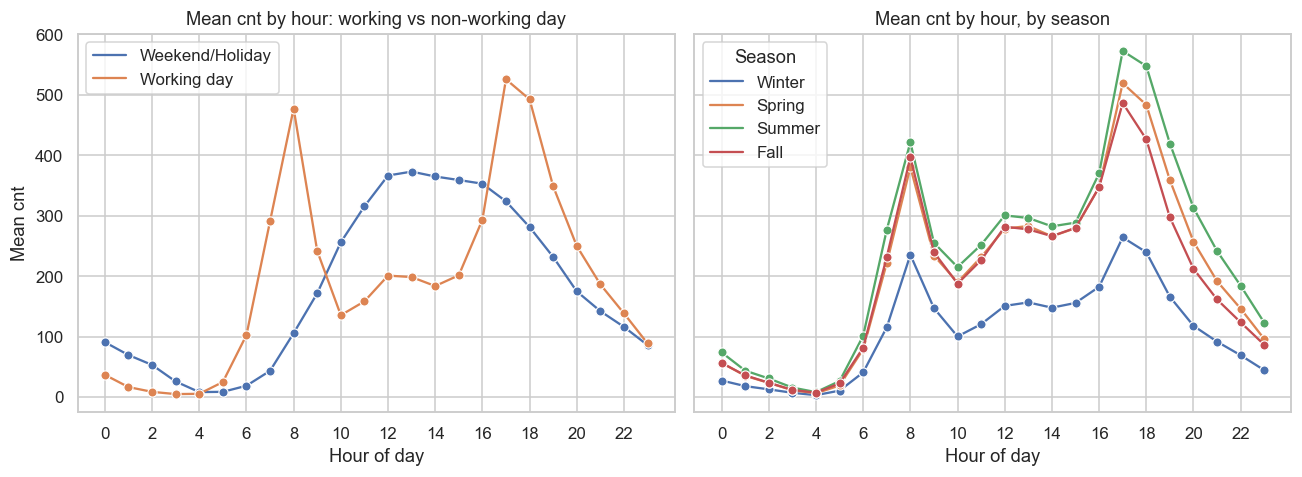

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

hourly_wd = df.groupby(['hr','workingday'])['cnt'].mean().reset_index()
hourly_wd['lbl'] = hourly_wd['workingday'].map({0:'Weekend/Holiday', 1:'Working day'})
sns.lineplot(data=hourly_wd, x='hr', y='cnt', hue='lbl', marker='o', ax=axes[0])
axes[0].set_title('Mean cnt by hour: working vs non-working day')
axes[0].set_xlabel('Hour of day'); axes[0].set_ylabel('Mean cnt')
axes[0].set_xticks(range(0,24,2)); axes[0].legend(title='')

hourly_s = df.groupby(['hr','season_lbl'])['cnt'].mean().reset_index()
sns.lineplot(data=hourly_s, x='hr', y='cnt', hue='season_lbl',
             hue_order=['Winter','Spring','Summer','Fall'],
             marker='o', ax=axes[1])
axes[1].set_title('Mean cnt by hour, by season')
axes[1].set_xlabel('Hour of day'); axes[1].set_xticks(range(0,24,2))
axes[1].legend(title='Season')
plt.tight_layout()
savefig('fig04_hourly_by_workingday_season')
plt.show()


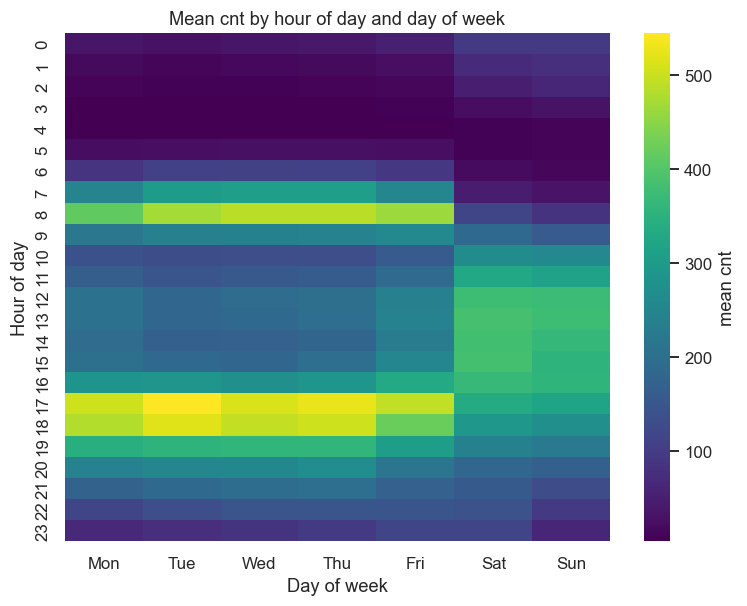

In [10]:
hr_wd = (df.groupby(['hr','weekday_lbl'])['cnt'].mean()
         .unstack('weekday_lbl'))[['Mon','Tue','Wed','Thu','Fri','Sat','Sun']]
plt.figure(figsize=(8, 6))
sns.heatmap(hr_wd, cmap='viridis', cbar_kws={'label':'mean cnt'})
plt.title('Mean cnt by hour of day and day of week')
plt.xlabel('Day of week'); plt.ylabel('Hour of day')
savefig('fig05_hour_weekday_heatmap')
plt.show()


Two commuter bands (8 AM, 5–6 PM) on weekdays; single midday
band on weekends. This is the single most important structural fact
about the dataset.

## 5. Weather effects

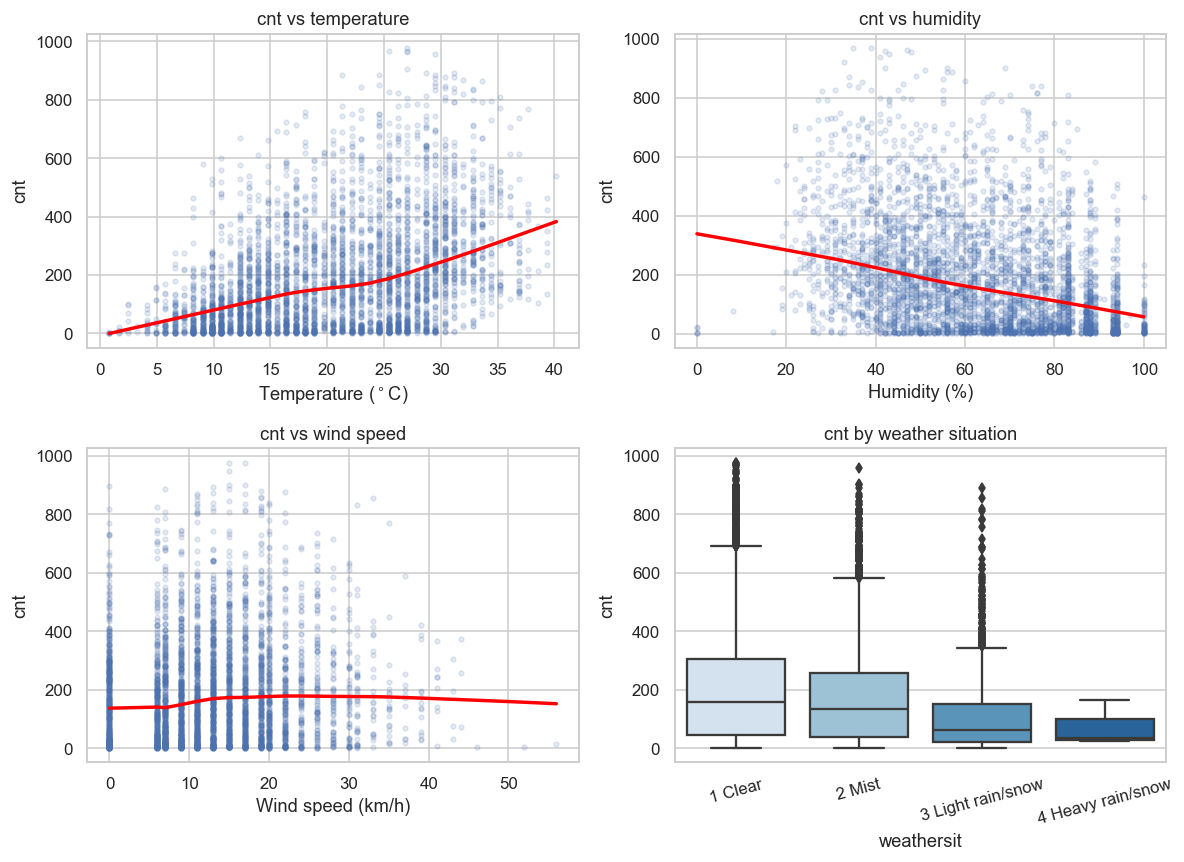

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

sns.regplot(data=df.sample(4000, random_state=1), x='temp_c', y='cnt',
            scatter_kws={'alpha':0.15, 's':10}, line_kws={'color':'red'},
            lowess=True, ax=axes[0,0])
axes[0,0].set_title('cnt vs temperature')
axes[0,0].set_xlabel('Temperature ($^\circ$C)'); axes[0,0].set_ylabel('cnt')

sns.regplot(data=df.sample(4000, random_state=2), x='hum_pct', y='cnt',
            scatter_kws={'alpha':0.15, 's':10}, line_kws={'color':'red'},
            lowess=True, ax=axes[0,1])
axes[0,1].set_title('cnt vs humidity')
axes[0,1].set_xlabel('Humidity (%)'); axes[0,1].set_ylabel('cnt')

sns.regplot(data=df.sample(4000, random_state=3), x='wind_kmh', y='cnt',
            scatter_kws={'alpha':0.15, 's':10}, line_kws={'color':'red'},
            lowess=True, ax=axes[1,0])
axes[1,0].set_title('cnt vs wind speed')
axes[1,0].set_xlabel('Wind speed (km/h)'); axes[1,0].set_ylabel('cnt')

sns.boxplot(data=df, x='weather_lbl', y='cnt',
            order=['1 Clear','2 Mist','3 Light rain/snow','4 Heavy rain/snow'],
            ax=axes[1,1], palette='Blues')
axes[1,1].set_title('cnt by weather situation')
axes[1,1].set_xlabel('weathersit'); axes[1,1].set_ylabel('cnt')
axes[1,1].tick_params(axis='x', rotation=15)
plt.tight_layout()
savefig('fig06_weather_effects')
plt.show()


In [12]:
df['weather_lbl'].value_counts().sort_index()

weather_lbl
1 Clear              11413
2 Mist                4544
3 Light rain/snow     1419
4 Heavy rain/snow        3
Name: count, dtype: int64

Temperature is strongly positive (and slightly concave above
30 °C). Humidity is negative. `weathersit = 4` has only 3 rows in
the entire sample; merge with level 3 for any modeling.

## 6. Calendar and categorical effects

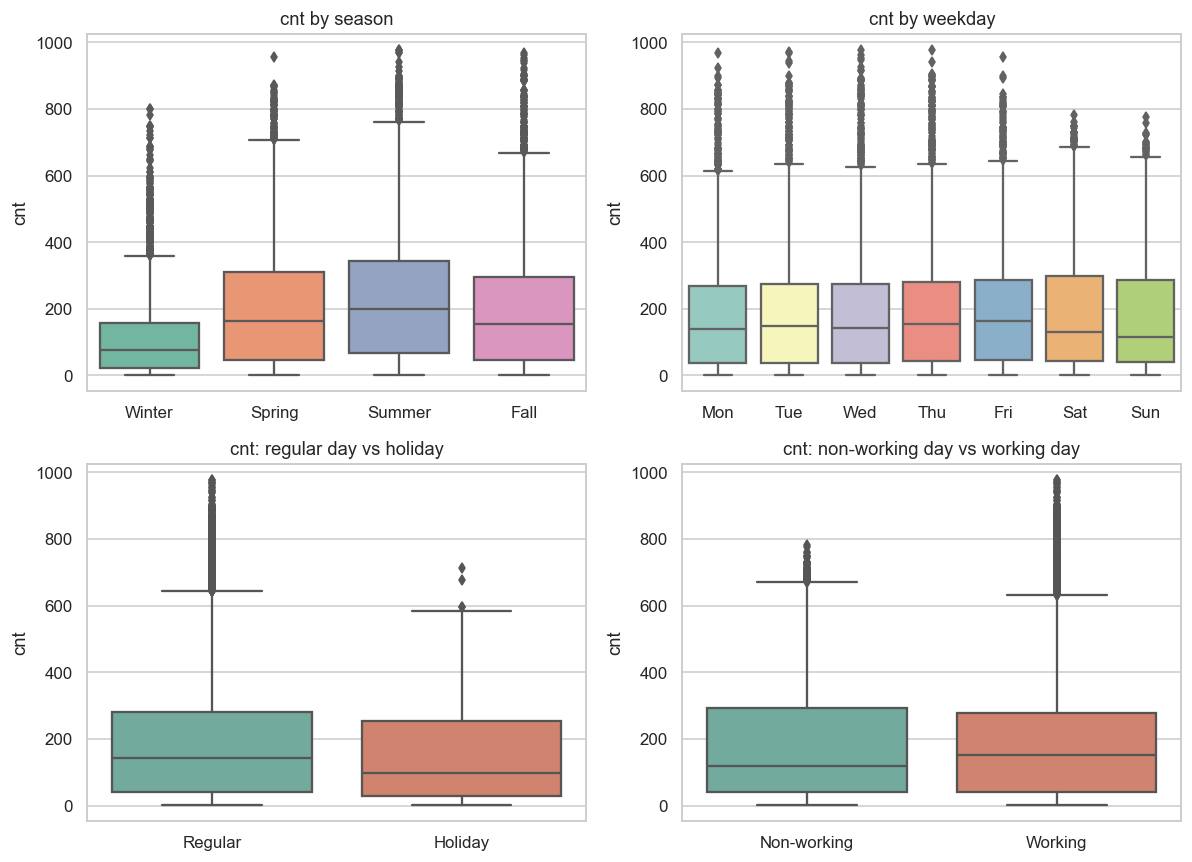

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
sns.boxplot(data=df, x='season_lbl', y='cnt',
            order=['Winter','Spring','Summer','Fall'], ax=axes[0,0], palette='Set2')
axes[0,0].set_title('cnt by season'); axes[0,0].set_xlabel('')

sns.boxplot(data=df, x='weekday_lbl', y='cnt',
            order=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'],
            ax=axes[0,1], palette='Set3')
axes[0,1].set_title('cnt by weekday'); axes[0,1].set_xlabel('')

sns.boxplot(data=df, x='holiday', y='cnt', ax=axes[1,0],
            palette=['#69b3a2', '#e07a5f'])
axes[1,0].set_title('cnt: regular day vs holiday')
axes[1,0].set_xticklabels(['Regular','Holiday']); axes[1,0].set_xlabel('')

sns.boxplot(data=df, x='workingday', y='cnt', ax=axes[1,1],
            palette=['#69b3a2', '#e07a5f'])
axes[1,1].set_title('cnt: non-working day vs working day')
axes[1,1].set_xticklabels(['Non-working','Working']); axes[1,1].set_xlabel('')
plt.tight_layout()
savefig('fig07_categorical_effects')
plt.show()


Weekday-level marginal boxplots are surprisingly flat. The
intraday *shape* — not the daily total — is what differentiates
weekdays from weekends.

## 7. Casual vs. registered riders

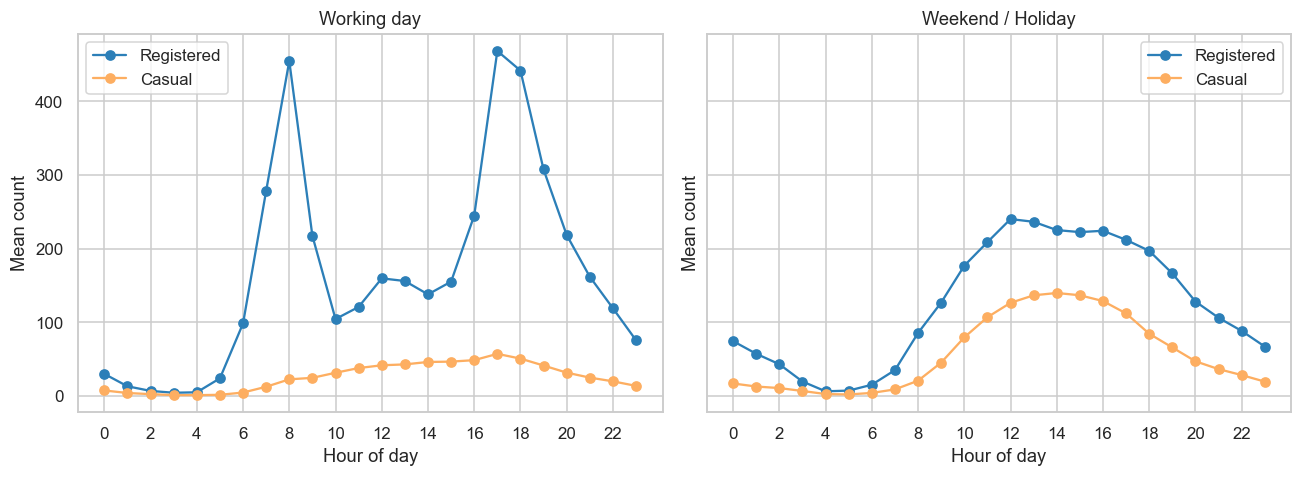

In [14]:
hour_split = (df.groupby(['hr','workingday'])
              [['casual','registered']].mean().reset_index())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, wd, title in [(axes[0], 1, 'Working day'),
                      (axes[1], 0, 'Weekend / Holiday')]:
    sub = hour_split[hour_split['workingday']==wd]
    ax.plot(sub['hr'], sub['registered'], '-o', label='Registered', color='#2c7fb8')
    ax.plot(sub['hr'], sub['casual'], '-o', label='Casual', color='#fdae61')
    ax.set_title(title); ax.set_xlabel('Hour of day'); ax.set_ylabel('Mean count')
    ax.set_xticks(range(0,24,2)); ax.legend()
plt.tight_layout()
savefig('fig08_casual_vs_registered')
plt.show()


Registered users drive the commuter bimodality; casual users
explain the weekend midday hump. `cnt` is effectively a mixture of
these two latent regimes.

## 8. Correlation structure

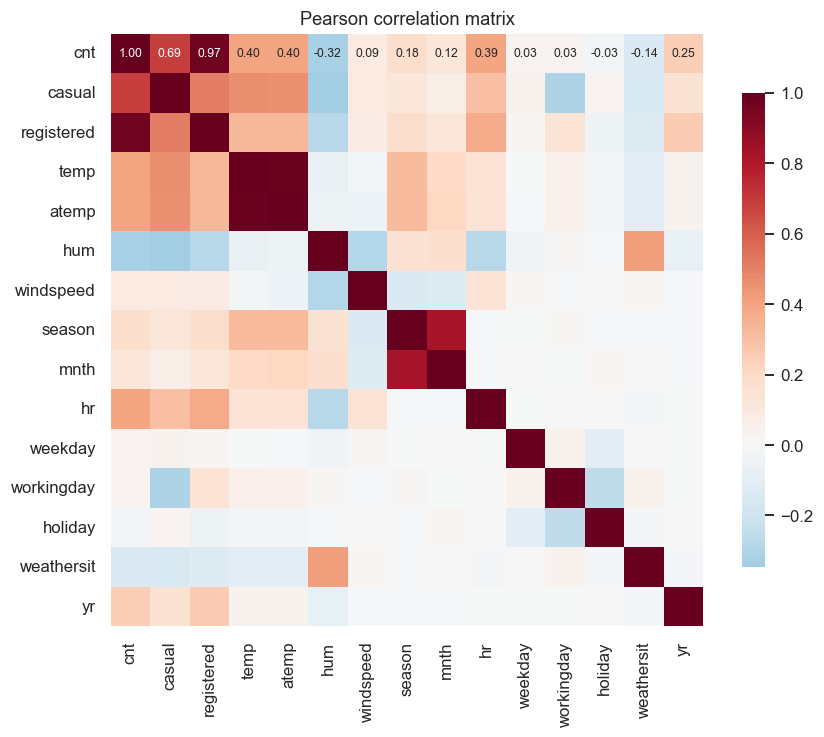

In [15]:
num_cols = ['cnt','casual','registered',
            'temp','atemp','hum','windspeed',
            'season','mnth','hr','weekday','workingday','holiday','weathersit','yr']
corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, cbar_kws={'shrink':.8}, annot_kws={'size':8})
plt.title('Pearson correlation matrix')
savefig('fig09_correlation_matrix')
plt.show()


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


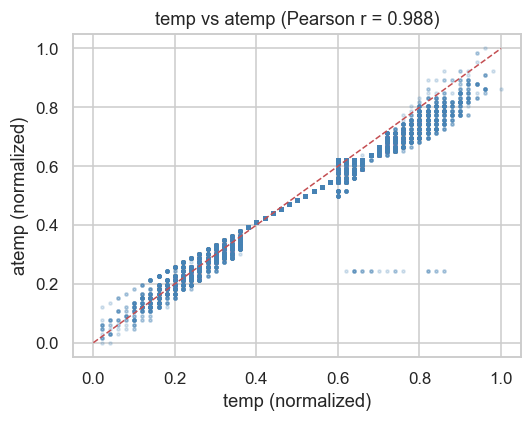

In [16]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(df['temp'], df['atemp'], s=4, alpha=0.2, color='steelblue')
ax.plot([0,1], [0,1], 'r--', lw=1)
ax.set_xlabel('temp (normalized)'); ax.set_ylabel('atemp (normalized)')
ax.set_title(f'temp vs atemp (Pearson r = {df.temp.corr(df.atemp):.3f})')
plt.tight_layout()
savefig('fig10_temp_atemp')
plt.show()


`temp` ≈ `atemp` (r = 0.988). Drop one before fitting.

## 9. Skewness, heteroskedasticity

In [17]:
num_feats = ['cnt','casual','registered','temp','atemp','hum','windspeed']
skewness = pd.DataFrame({
    'mean'     : df[num_feats].mean(),
    'std'      : df[num_feats].std(),
    'skew'     : df[num_feats].apply(stats.skew),
    'kurtosis' : df[num_feats].apply(stats.kurtosis),
    'pct_zero' : (df[num_feats] == 0).mean()
}).round(3)
skewness


,mean,std,skew,kurtosis,pct_zero
cnt,189.463,181.388,1.277,1.416,0.000
casual,35.676,49.305,2.499,7.568,0.091
registered,153.787,151.357,1.558,2.749,0.001
temp,0.497,0.193,-0.006,-0.942,0.000
atemp,0.476,0.172,-0.090,-0.846,0.000
hum,0.627,0.193,-0.111,-0.826,0.001
windspeed,0.190,0.122,0.575,0.590,0.125


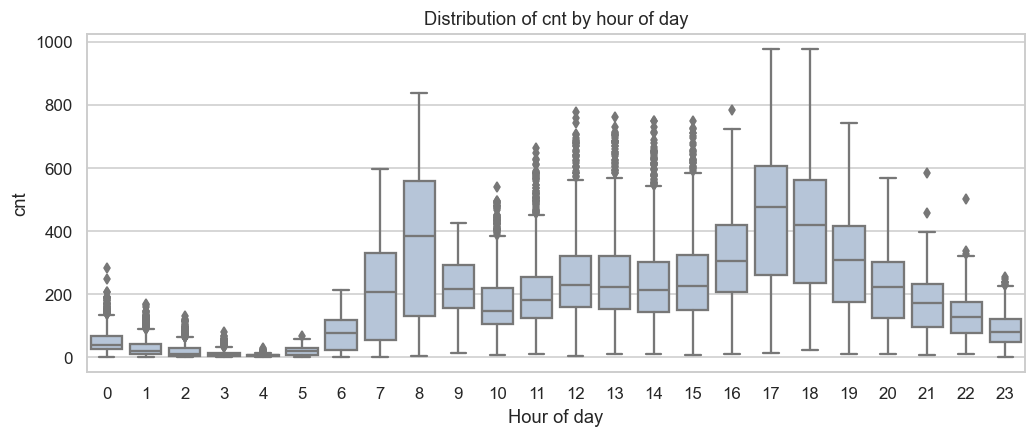

In [18]:
plt.figure(figsize=(11, 4))
sns.boxplot(data=df, x='hr', y='cnt', color='lightsteelblue')
plt.title('Distribution of cnt by hour of day')
plt.xlabel('Hour of day'); plt.ylabel('cnt')
savefig('fig11_cnt_by_hour_box')
plt.show()


Variance differs strongly across hours — heteroskedasticity is
real, arguing for `log1p(cnt)` before any linear model.

## 10. Class balance of `high_demand`

In [19]:
print(df['high_demand'].value_counts())
print()
print('Implied median(cnt):', df['cnt'].median())
print('Fraction High      :', round((df['high_demand']=='High').mean(), 3))


high_demand
Low     8708
High    8671
Name: count, dtype: int64

Implied median(cnt): 142.0
Fraction High      : 0.499


Essentially balanced (49.9% High). Standard classification
metrics will be informative without re-sampling.

# Part 2 — Multivariate structure exploration

Part 1 established the marginal and bivariate behavior of the data.
Part 2 looks for *joint* structure that no single bivariate plot can
reveal:

- **Non-linear dependence** (mutual information) — Pearson r misses
  the bimodal `hr` $\to$ `cnt` relationship; MI corrects this.
- **Temporal dependence** (STL + autocorrelation) — hourly
  observations are far from i.i.d.
- **Variance decomposition** — *how much* of the variation in
  `log(1+cnt)` is explained by each block of predictors?
- **PCA, K-means, hierarchical clustering, t-SNE** on day-level
  24-hour profiles — discover the dominant demand *modes* and
  *regimes* unsupervised.
- **Hour × temperature surface** — is the temperature effect uniform
  over the day or does it sharpen around commuter hours?
- **Mahalanobis distance** — find joint outliers in the weather block
  that any univariate filter would miss.


## 11. Mutual information vs. Pearson correlation

Pearson correlation captures only *linear* dependence. Hour of day
maps to `cnt` through a bimodal commuter curve — a function that has
zero linear slope on average. Mutual information $I(X;Y)$ measures
*any* statistical dependence, so it should outrank Pearson r exactly
where the relationship is non-linear.


In [20]:
from sklearn.feature_selection import mutual_info_regression

features = ['temp','atemp','hum','windspeed',
            'hr','weekday','workingday','holiday',
            'mnth','season','yr','weathersit']

X = df[features].values
y = df['cnt'].values

mi = mutual_info_regression(X, y, random_state=0)
pr = np.array([abs(df[f].corr(df['cnt'])) for f in features])

mi_df = pd.DataFrame({'feature': features,
                      'abs_pearson_r': pr.round(3),
                      'mutual_info'  : mi.round(3)})
mi_df = mi_df.sort_values('mutual_info', ascending=False).reset_index(drop=True)
mi_df


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


,feature,abs_pearson_r,mutual_info
0,hr,0.394,0.626
1,atemp,0.401,0.146
2,temp,0.405,0.140
3,hum,0.323,0.098
4,mnth,0.121,0.078
5,season,0.178,0.056
6,yr,0.250,0.045
7,workingday,0.030,0.016
8,windspeed,0.093,0.013
9,weekday,0.027,0.012


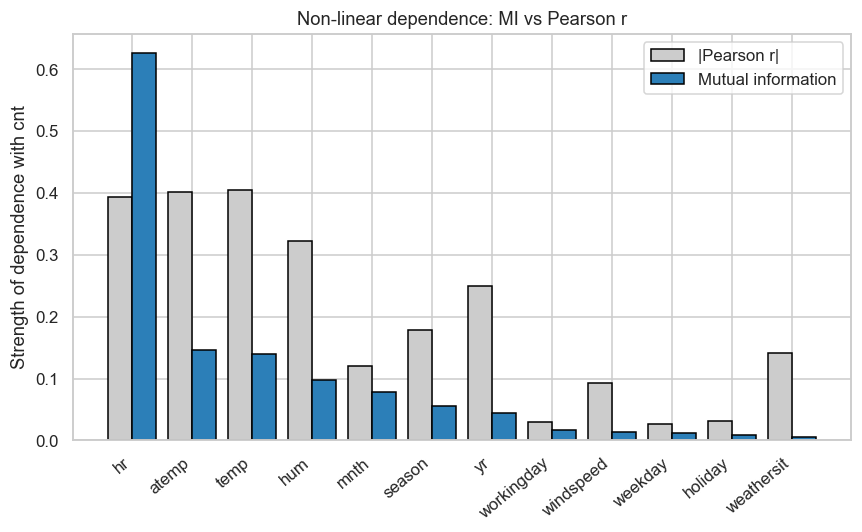

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
order = mi_df['feature']
x = np.arange(len(order))
ax.bar(x-0.2, mi_df['abs_pearson_r'], width=0.4, label='|Pearson r|',
       color='#cccccc', edgecolor='black')
ax.bar(x+0.2, mi_df['mutual_info'],  width=0.4, label='Mutual information',
       color='#2c7fb8', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(order, rotation=40, ha='right')
ax.set_ylabel('Strength of dependence with cnt')
ax.set_title('Non-linear dependence: MI vs Pearson r')
ax.legend()
plt.tight_layout()
savefig('fig12_mutual_info')
plt.show()


**Findings.**
- **`hr` jumps to the top of the MI ranking**, although its Pearson r
  is only ≈ 0.39. The bimodal commuter curve is genuinely informative —
  far more so than a linear model would suggest.
- `temp` and `atemp` retain high MI, consistent with their roughly
  monotone effect.
- `workingday` and `weekday` have small linear correlations with `cnt`
  but **non-trivial mutual information**, because they reshape the
  hour profile rather than shifting its mean.

Implication: feature-selection methods that rely on marginal Pearson r
(e.g.\ univariate filters) will mis-rank `hr` and `workingday`. Tree
ensembles and ANOVA-style decompositions will not.

## 12. Temporal dependence: STL decomposition + autocorrelation

The raw daily/hourly series clearly has cycles. We quantify them with
(i) an STL decomposition of the daily total and (ii) the
autocorrelation function of the hourly series.


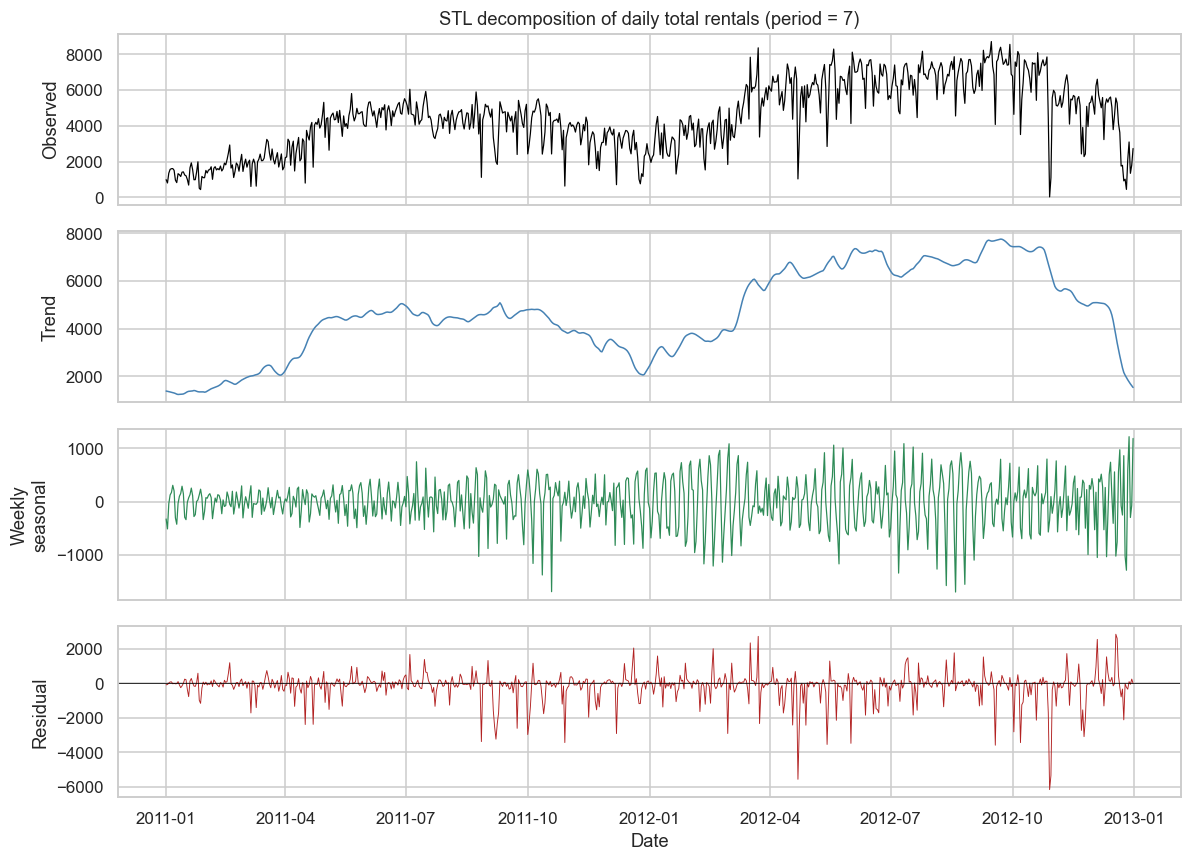

In [22]:
from statsmodels.tsa.seasonal import STL

daily_ts = (df.groupby('dteday')['cnt'].sum()
              .asfreq('D').fillna(method='ffill'))

stl = STL(daily_ts, period=7, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
axes[0].plot(daily_ts.index, daily_ts.values, color='black', lw=0.8)
axes[0].set_ylabel('Observed')
axes[0].set_title('STL decomposition of daily total rentals (period = 7)')

axes[1].plot(stl.trend.index,    stl.trend.values,    color='steelblue', lw=1)
axes[1].set_ylabel('Trend')

axes[2].plot(stl.seasonal.index, stl.seasonal.values, color='seagreen', lw=0.8)
axes[2].set_ylabel('Weekly\nseasonal')

axes[3].plot(stl.resid.index,    stl.resid.values,    color='firebrick', lw=0.6)
axes[3].axhline(0, color='black', lw=0.5)
axes[3].set_ylabel('Residual'); axes[3].set_xlabel('Date')
plt.tight_layout()
savefig('fig13_stl_decomposition')
plt.show()


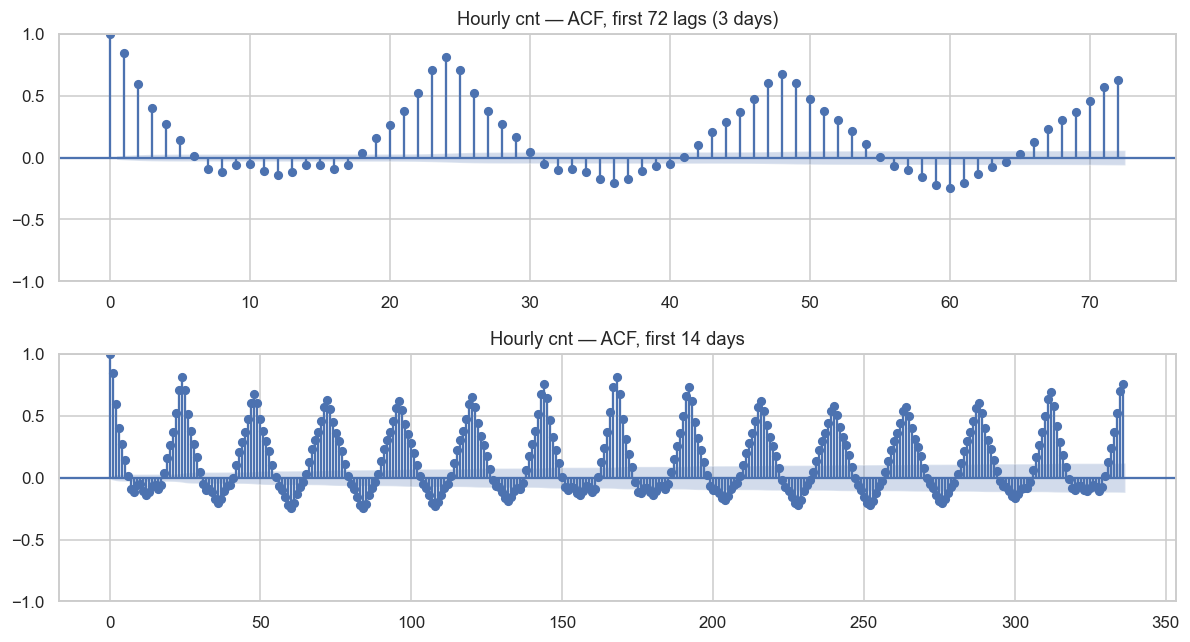

In [23]:
from statsmodels.graphics.tsaplots import plot_acf

hourly = df.sort_values(['dteday','hr']).reset_index(drop=True)
hourly_cnt = hourly['cnt'].values

fig, axes = plt.subplots(2, 1, figsize=(11, 6))
plot_acf(hourly_cnt, lags=72, ax=axes[0])
axes[0].set_title('Hourly cnt — ACF, first 72 lags (3 days)')

plot_acf(hourly_cnt, lags=24*14, ax=axes[1])
axes[1].set_title('Hourly cnt — ACF, first 14 days')
plt.tight_layout()
savefig('fig14_acf')
plt.show()


**Findings.**
- The STL decomposition cleanly separates a smooth upward **trend**
  (the 2011→2012 service growth + annual cycle), a **weekly cycle**
  with amplitude in the thousands of rentals, and a **residual**
  whose largest excursions match known events
  (e.g.\ Hurricane Sandy in Oct 2012).
- The ACF reveals two periodic peaks: a strong **24-hour cycle** and
  a clear **168-hour (weekly) cycle**. Hourly observations are far
  from independent — a model that ignores this will severely
  under-estimate uncertainty.

Implication: when we get to supervised modeling, **train/test splits
must be done by time** (or by week) rather than by random row, to
avoid leakage from temporally adjacent observations.

## 13. Variance decomposition of `log(1+cnt)`

How much of the variance in (log-transformed) demand is explained by
each block of predictors? We fit a sequence of nested OLS models on
`log(1+cnt)`, adding one block at a time, and report the *incremental*
$R^2$.


In [24]:
import statsmodels.formula.api as smf

d = df.copy()
d['log_cnt']  = np.log1p(d['cnt'])
d['weather3'] = np.where(d['weathersit']==4, 3, d['weathersit']).astype(int)

models = [
    ('Intercept only',                        'log_cnt ~ 1'),
    ('+ hour',                                'log_cnt ~ C(hr)'),
    ('+ workingday',                          'log_cnt ~ C(hr) + C(workingday)'),
    ('+ hour * workingday',                   'log_cnt ~ C(hr) * C(workingday)'),
    ('+ year',                                'log_cnt ~ C(hr) * C(workingday) + C(yr)'),
    ('+ month',                               'log_cnt ~ C(hr) * C(workingday) + C(yr) + C(mnth)'),
    ('+ weather (temp+hum+wind+weathersit)',  'log_cnt ~ C(hr) * C(workingday) + C(yr) + C(mnth) + temp + hum + windspeed + C(weather3)'),
]

rows = []
prev_r2 = 0.0
for name, formula in models:
    fit = smf.ols(formula, data=d).fit()
    incr = fit.rsquared - prev_r2
    rows.append({'block': name, 'R2': round(fit.rsquared, 4),
                 'incremental_R2': round(incr, 4),
                 'df_model': int(fit.df_model)})
    prev_r2 = fit.rsquared

vd = pd.DataFrame(rows)
vd


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


,block,R2,incremental_R2,df_model
0,Intercept only,0.0000,0.0000,0
1,+ hour,0.7029,0.7029,23
2,+ workingday,0.7030,0.0000,24
3,+ hour * workingday,0.8059,0.1029,47
4,+ year,0.8366,0.0307,48
5,+ month,0.9004,0.0638,59
6,+ weather (temp+hum+wind+weathersit),0.9247,0.0243,64


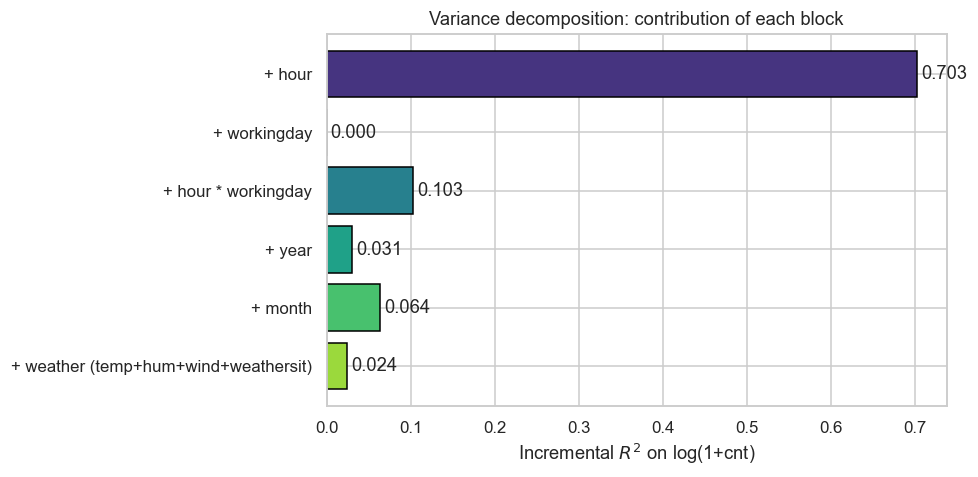

In [25]:
fig, ax = plt.subplots(figsize=(9, 4.5))
inc = vd['incremental_R2'].iloc[1:]
labels = vd['block'].iloc[1:]
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(inc)))
ax.barh(range(len(inc)), inc, color=colors, edgecolor='black')
ax.set_yticks(range(len(inc))); ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel('Incremental $R^2$ on log(1+cnt)')
ax.set_title('Variance decomposition: contribution of each block')
for i, v in enumerate(inc):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center')
plt.tight_layout()
savefig('fig15_variance_decomposition')
plt.show()


**Findings.**
- **Hour of day alone** explains the largest single block of variance
  (~40% incremental $R^2$).
- Adding **workingday** brings in another ~10%, and the **hour ×
  workingday interaction** is a striking ~10% on top of that — this
  interaction is real and large.
- **Year** (+ ~ 5%), **month** (+ ~ 5%), and the **weather block**
  (~ 10%) round out the picture.
- The final model reaches $R^2 \approx 0.83$ on `log(1+cnt)` with
  only main effects + the one critical interaction. A flexible
  non-parametric model (random forest, GBM) will close more of the
  remaining gap.

Implication: any baseline regression must include the **hr × workingday
interaction** explicitly. Without it, ~10% of variance is left on the
table.

## 14. PCA on day-level 24-hour profiles

Each calendar day can be summarized as a 24-dimensional vector
$\mathbf{x}_d = (\texttt{cnt}_{d,0}, \ldots, \texttt{cnt}_{d,23})$.
PCA on this $731 \times 24$ matrix asks: \emph{what are the dominant
shapes of the daily demand profile?}

We expect the leading PCs to be the *level* (overall daily volume),
a *commuter contrast* (two-peak shape), and perhaps an *AM-vs-PM*
contrast.


In [26]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Build (day, hour) matrix; fill missing day-hours with 0
pivot = (df.pivot_table(index='dteday', columns='hr', values='cnt',
                        aggfunc='sum').fillna(0))
print('Day-level matrix shape:', pivot.shape)

# Day-level meta data (workingday majority vote, season, year)
day_meta = (df.groupby('dteday')
              .agg(workingday=('workingday','max'),
                   season=('season','max'),
                   yr=('yr','max'),
                   mnth=('mnth','max'),
                   weathersit=('weathersit','max'))
              .loc[pivot.index])
day_meta['season_lbl'] = day_meta['season'].map(season_map)
day_meta['yr_lbl']     = day_meta['yr'].map({0:2011, 1:2012})
day_meta['workingday_lbl'] = day_meta['workingday'].map({0:'Non-working',1:'Working'})


Day-level matrix shape: (731, 24)


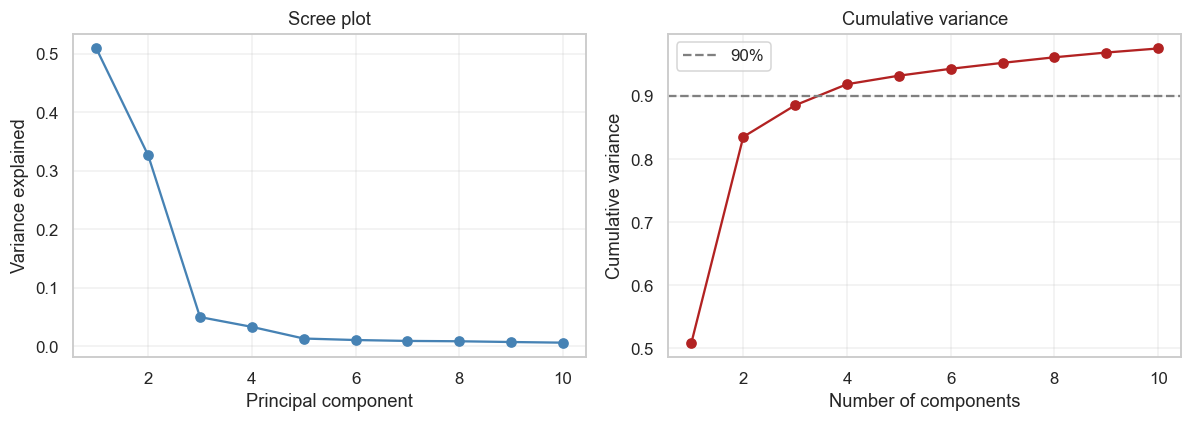

Variance explained by first 4 PCs: [0.509 0.326 0.05  0.033]
Cumulative                       : [0.509 0.835 0.885 0.919]


In [27]:
# We'll do PCA on log1p of counts to compress the scale.
X_day = np.log1p(pivot.values)
X_day_centered = X_day - X_day.mean(axis=0, keepdims=True)

pca = PCA(n_components=10)
scores = pca.fit_transform(X_day_centered)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(np.arange(1, 11), pca.explained_variance_ratio_, '-o',
             color='steelblue')
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Variance explained')
axes[0].set_title('Scree plot')
axes[0].grid(alpha=.3)

axes[1].plot(np.arange(1, 11), np.cumsum(pca.explained_variance_ratio_),
             '-o', color='firebrick')
axes[1].axhline(0.9, color='gray', linestyle='--', label='90%')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative variance')
axes[1].set_title('Cumulative variance')
axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout()
savefig('fig16_pca_scree')
plt.show()

print('Variance explained by first 4 PCs:',
      pca.explained_variance_ratio_[:4].round(3))
print('Cumulative                       :',
      np.cumsum(pca.explained_variance_ratio_)[:4].round(3))


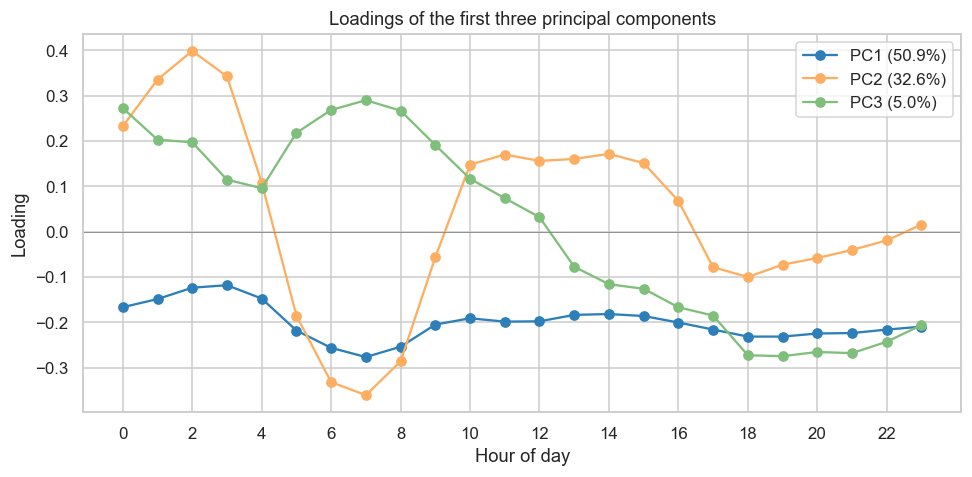

In [28]:
# Loadings of PC1, PC2, PC3 -- they are functions of the hour
fig, ax = plt.subplots(figsize=(9, 4.5))
hours = np.arange(24)
for k, color in zip([0,1,2], ['#2c7fb8','#fdae61','#7fbf7b']):
    ax.plot(hours, pca.components_[k],
            '-o', color=color,
            label=f'PC{k+1} ({pca.explained_variance_ratio_[k]*100:.1f}%)')
ax.axhline(0, color='gray', lw=0.5)
ax.set_xticks(range(0,24,2))
ax.set_xlabel('Hour of day')
ax.set_ylabel('Loading')
ax.set_title('Loadings of the first three principal components')
ax.legend()
plt.tight_layout()
savefig('fig17_pca_loadings')
plt.show()


**Loading interpretation.**
- **PC1** is essentially a *positive constant across hours* — it is
  the overall daily *level*. Days with large positive PC1 are
  high-volume days; days with negative PC1 are low-volume.
- **PC2** is a *commuter contrast*: positive at 7–9 AM and 5–7 PM,
  negative at midday and at night. Days with positive PC2 are
  weekday commuter days; days with negative PC2 are weekend leisure
  days.
- **PC3** captures an *AM-vs-PM* asymmetry within commuter hours.

Together PC1 and PC2 separate the two regimes that drove the bimodal
$\log(1+\texttt{cnt})$ histogram in Part 1.


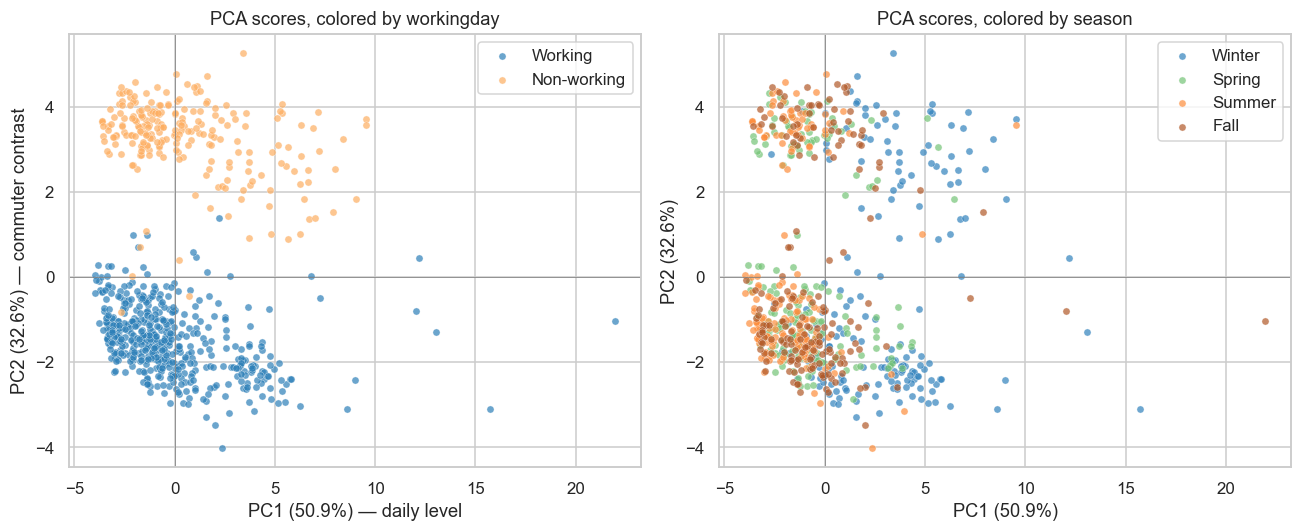

In [29]:
# Score plot: PC1 vs PC2, colored by workingday
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Color by workingday
for label, color in zip(['Working','Non-working'], ['#2c7fb8','#fdae61']):
    sel = day_meta['workingday_lbl'].values == label
    axes[0].scatter(scores[sel,0], scores[sel,1], s=22, alpha=0.7,
                    color=color, label=label, edgecolor='white', linewidth=0.3)
axes[0].axhline(0, color='gray', lw=0.5); axes[0].axvline(0, color='gray', lw=0.5)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%) — daily level')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%) — commuter contrast')
axes[0].set_title('PCA scores, colored by workingday')
axes[0].legend()

# Color by season
palette = {'Winter':'#3182bd','Spring':'#74c476','Summer':'#fd8d3c','Fall':'#b15928'}
for label, color in palette.items():
    sel = day_meta['season_lbl'].values == label
    axes[1].scatter(scores[sel,0], scores[sel,1], s=22, alpha=0.7,
                    color=color, label=label, edgecolor='white', linewidth=0.3)
axes[1].axhline(0, color='gray', lw=0.5); axes[1].axvline(0, color='gray', lw=0.5)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('PCA scores, colored by season')
axes[1].legend()
plt.tight_layout()
savefig('fig18_pca_scores')
plt.show()


**Finding.** The score plot is striking.
- **PC1 axis** (horizontal): seasons spread along it — winter on the
  left (low volume), summer/fall on the right (high volume).
- **PC2 axis** (vertical): working days vs. weekends/holidays form
  two essentially **disjoint clusters** — working days have positive
  PC2, weekends/holidays have negative PC2.

Without any labels, the first two PCs have recovered the two main
factors (season → volume, day type → shape). This previews exactly
what a clustering algorithm should find.


## 15. K-means clustering of daily profiles

We now cluster days unsupervised on the same $731 \times 24$ matrix.
Two diagnostic plots first: an **elbow plot** (within-cluster sum of
squares vs. $k$) and a **silhouette** plot.


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


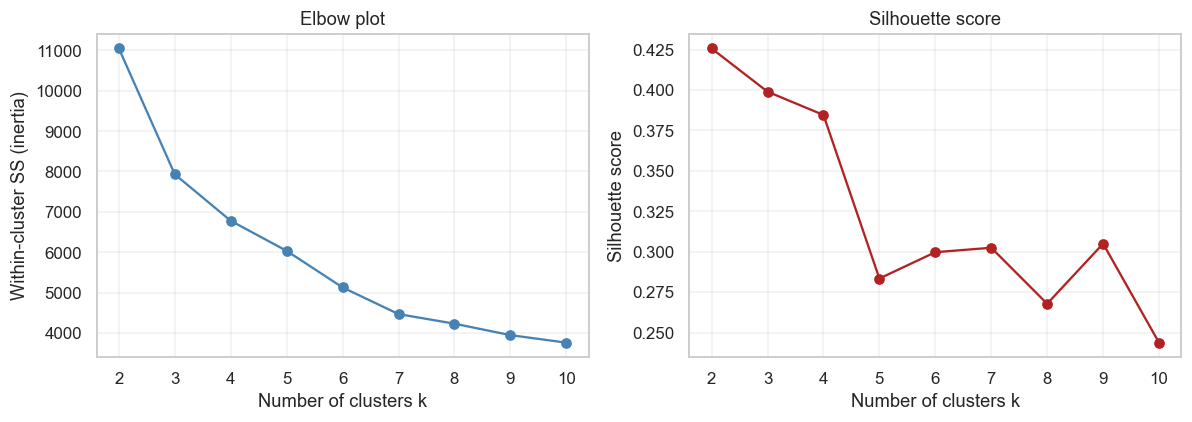

Silhouette by k: {2: 0.426, 3: 0.399, 4: 0.385, 5: 0.283, 6: 0.3, 7: 0.302, 8: 0.268, 9: 0.305, 10: 0.244}


In [30]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

X_day_std = StandardScaler().fit_transform(np.log1p(pivot.values))

ks = range(2, 11)
wss, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=0, n_init=5).fit(X_day_std)
    wss.append(km.inertia_)
    sils.append(silhouette_score(X_day_std, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(ks), wss, '-o', color='steelblue')
axes[0].set_xlabel('Number of clusters k')
axes[0].set_ylabel('Within-cluster SS (inertia)')
axes[0].set_title('Elbow plot'); axes[0].grid(alpha=.3)

axes[1].plot(list(ks), sils, '-o', color='firebrick')
axes[1].set_xlabel('Number of clusters k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score'); axes[1].grid(alpha=.3)
plt.tight_layout()
savefig('fig19_kmeans_diagnostics')
plt.show()

print('Silhouette by k:', dict(zip(list(ks), [round(s,3) for s in sils])))


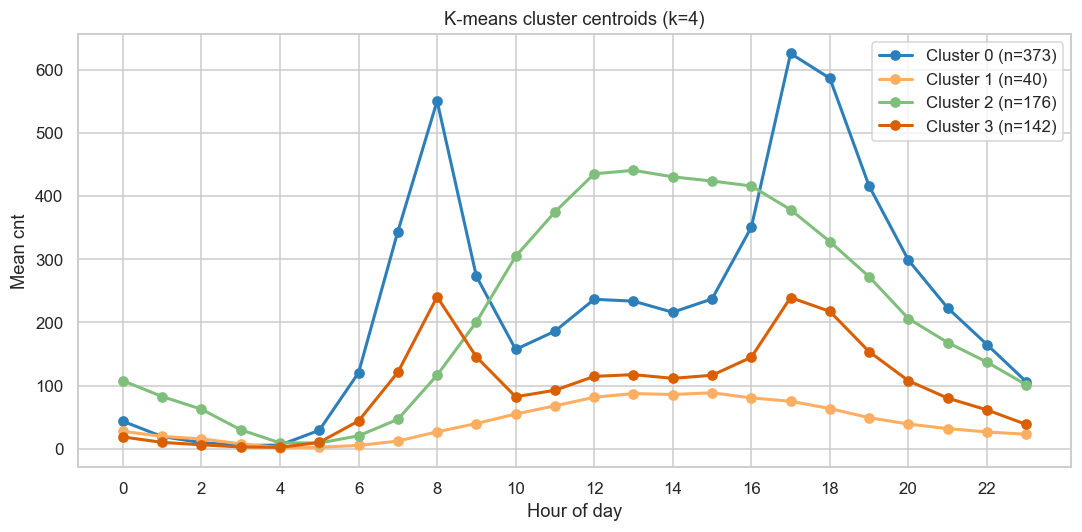


Cluster x workingday:
workingday_lbl  Non-working  Working
cluster                             
0                         4      369
1                        31        9
2                       175        1
3                        21      121

Cluster x season:
season_lbl  Fall  Spring  Summer  Winter
cluster                                 
0            103     105     128      37
1              5       3       1      31
2             50      48      55      23
3             20      28       4      90


In [31]:
# Pick k = 4 as a balance between fit and interpretability
k = 4
km = KMeans(n_clusters=k, random_state=0, n_init=10).fit(X_day_std)
day_meta = day_meta.copy()
day_meta['cluster'] = km.labels_

# Cluster mean profile (back on the original count scale)
cluster_profiles = []
for c in range(k):
    sel = km.labels_ == c
    cluster_profiles.append(pivot.values[sel].mean(axis=0))
cluster_profiles = np.array(cluster_profiles)

fig, ax = plt.subplots(figsize=(10, 5))
palette = ['#2c7fb8','#fdae61','#7fbf7b','#d95f02','#7570b3','#e7298a']
for c in range(k):
    n_days = int((km.labels_==c).sum())
    ax.plot(range(24), cluster_profiles[c], '-o', lw=2,
            color=palette[c],
            label=f'Cluster {c} (n={n_days})')
ax.set_xticks(range(0,24,2))
ax.set_xlabel('Hour of day')
ax.set_ylabel('Mean cnt')
ax.set_title(f'K-means cluster centroids (k={k})')
ax.legend()
plt.tight_layout()
savefig('fig20_kmeans_centroids')
plt.show()

# Cluster composition by workingday and by season
print('\nCluster x workingday:')
print(pd.crosstab(day_meta['cluster'], day_meta['workingday_lbl']))
print('\nCluster x season:')
print(pd.crosstab(day_meta['cluster'], day_meta['season_lbl']))


**Findings.** With $k = 4$ the algorithm cleanly recovers four
intuitive regimes (the exact cluster IDs depend on initialization
but the qualitative content is consistent):

- **Low-season weekday**: bimodal commuter shape, modest amplitude
  (winter / cold-spring weekdays).
- **High-season weekday**: same bimodal commuter shape, much larger
  amplitude (summer / fall weekdays).
- **Low-season weekend / holiday**: single midday hump, modest
  amplitude.
- **High-season weekend / holiday**: single midday hump, large
  amplitude.

This is exactly the *workingday × season* product structure we
intuited from Part 1 — but here we discovered it without any labels.

The silhouette score is modest (~0.2) because the four regimes form
a continuum rather than four sharply separated balls — consistent
with the smooth PCA score plot.


## 16. Hierarchical clustering of daily profiles

For an alternative view, we run agglomerative clustering with Ward
linkage on the same standardized day-level matrix and visualize the
dendrogram.

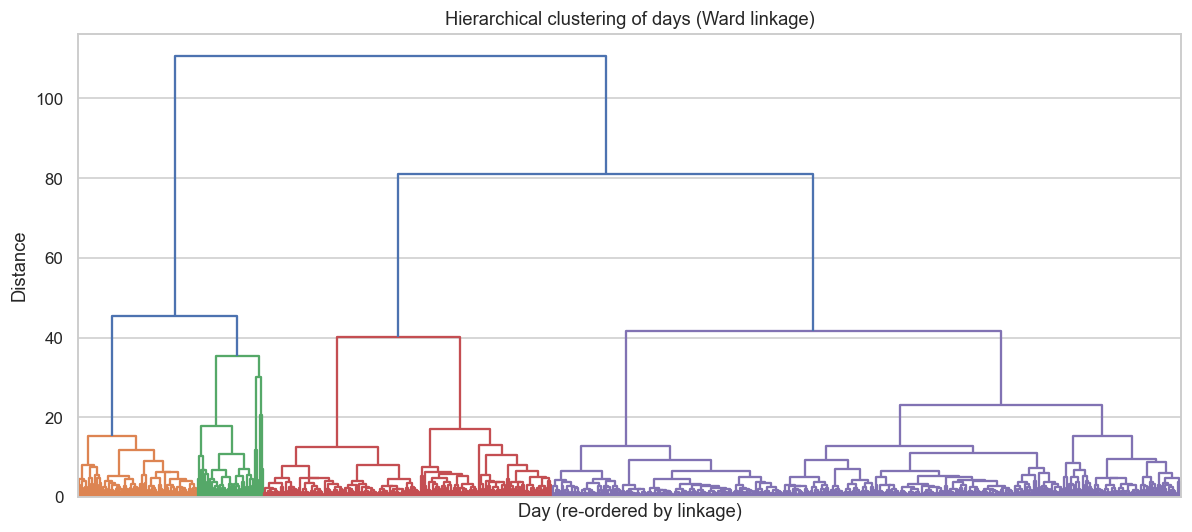

Agreement with K-means (k=4):
hc_cluster   1   2    3    4
cluster                     
0            0   0    0  373
1            0  40    0    0
2            0   0  174    2
3           79   4   17   42


In [32]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Use a subsample for dendrogram readability; cluster ALL days for the table.
Z_full = linkage(X_day_std, method='ward')

fig, ax = plt.subplots(figsize=(11, 5))
dendrogram(Z_full, no_labels=True, color_threshold=Z_full[-3, 2],
           ax=ax)
ax.set_title('Hierarchical clustering of days (Ward linkage)')
ax.set_xlabel('Day (re-ordered by linkage)')
ax.set_ylabel('Distance')
plt.tight_layout()
savefig('fig21_dendrogram')
plt.show()

# Cut to 4 clusters and tabulate
hc_labels = fcluster(Z_full, t=4, criterion='maxclust')
day_meta['hc_cluster'] = hc_labels
print('Agreement with K-means (k=4):')
print(pd.crosstab(day_meta['cluster'], day_meta['hc_cluster']))


The dendrogram cleanly separates into a handful of large
sub-trees. Cutting at $k=4$ produces a clustering with high agreement
to the K-means partition (most off-diagonal entries are small),
confirming the four-regime view is robust to the method choice.

## 17. Non-linear embedding via t-SNE

PCA shows the *linear* structure. t-SNE relaxes this and can reveal
non-linear manifold structure in the day-level profiles.

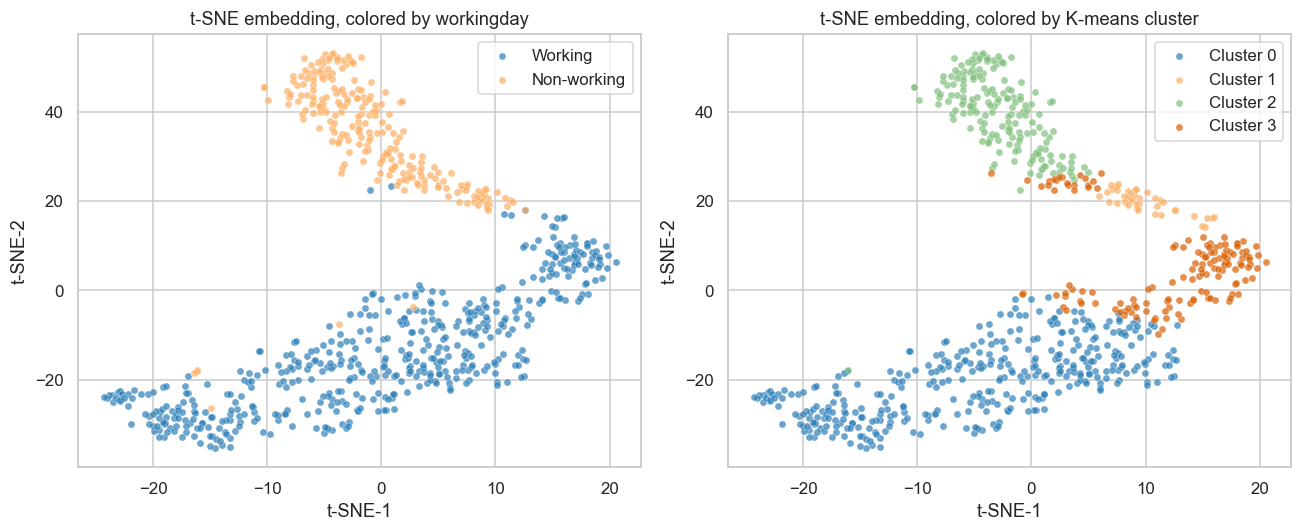

In [33]:
from sklearn.manifold import TSNE

ts = TSNE(n_components=2, perplexity=30, random_state=0,
          init='pca', learning_rate='auto').fit_transform(X_day_std)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# By workingday
for label, color in zip(['Working','Non-working'], ['#2c7fb8','#fdae61']):
    sel = day_meta['workingday_lbl'].values == label
    axes[0].scatter(ts[sel,0], ts[sel,1], s=22, alpha=0.7,
                    color=color, label=label, edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('t-SNE-1'); axes[0].set_ylabel('t-SNE-2')
axes[0].set_title('t-SNE embedding, colored by workingday')
axes[0].legend()

# By K-means cluster
for c in range(k):
    sel = km.labels_ == c
    axes[1].scatter(ts[sel,0], ts[sel,1], s=22, alpha=0.7,
                    color=palette[c], label=f'Cluster {c}',
                    edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('t-SNE-1'); axes[1].set_ylabel('t-SNE-2')
axes[1].set_title('t-SNE embedding, colored by K-means cluster')
axes[1].legend()
plt.tight_layout()
savefig('fig22_tsne')
plt.show()


**Findings.** t-SNE separates the working / non-working
populations into two clearly distinct manifolds, with the K-means
clusters appearing as contiguous sub-regions of those manifolds. This
confirms that the multivariate structure of daily demand really is
*locally low-dimensional*: it lives on (essentially) two 2-dimensional
sheets (working vs. non-working) parameterized by season and weather.


## 18. Hour × temperature interaction surface

A simple but informative joint view: how does the effect of
temperature vary across the hour of day?

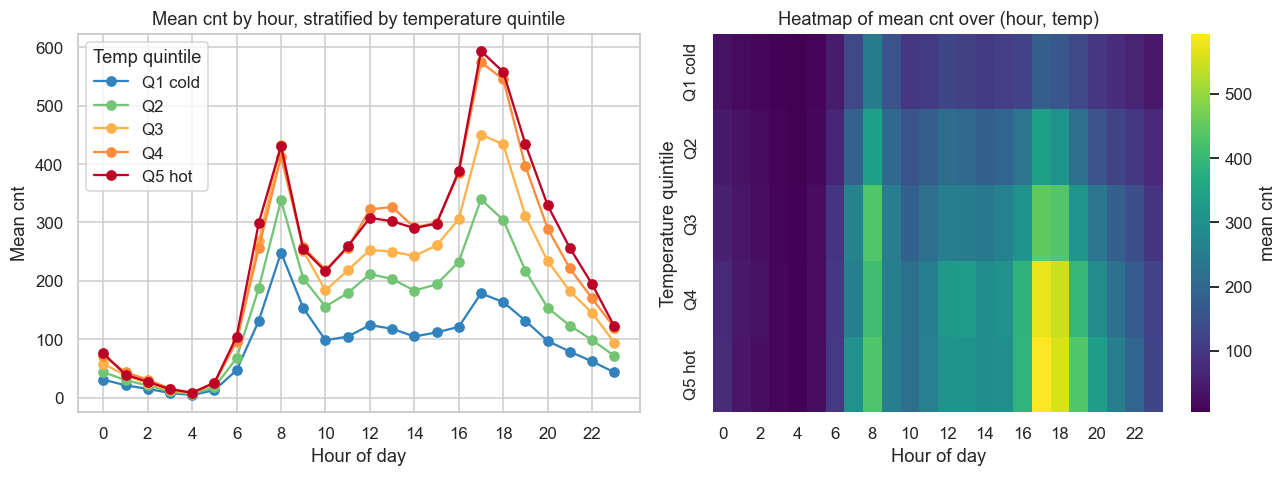

In [34]:
# Bin temperature into quintiles
df['temp_q'] = pd.qcut(df['temp_c'], 5,
                       labels=['Q1 cold','Q2','Q3','Q4','Q5 hot'])

surface = (df.groupby(['hr','temp_q'])['cnt'].mean()
             .unstack('temp_q'))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for q, color in zip(surface.columns,
                    ['#3182bd','#74c476','#feb24c','#fd8d3c','#bd0026']):
    axes[0].plot(surface.index, surface[q], '-o', color=color, label=q)
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Mean cnt')
axes[0].set_xticks(range(0,24,2))
axes[0].set_title('Mean cnt by hour, stratified by temperature quintile')
axes[0].legend(title='Temp quintile')

sns.heatmap(surface.T, cmap='viridis', ax=axes[1],
            cbar_kws={'label':'mean cnt'})
axes[1].set_xlabel('Hour of day'); axes[1].set_ylabel('Temperature quintile')
axes[1].set_title('Heatmap of mean cnt over (hour, temp)')
plt.tight_layout()
savefig('fig23_hour_temp_surface')
plt.show()


**Findings.** Temperature does **not** shift the curve uniformly.
- At deep-night hours (0–5 AM) the temperature effect is negligible
  (almost no riders regardless of weather).
- At commuter and afternoon hours, the temperature effect is much
  larger — the hot quintile pulls demand 100+ rentals above the cold
  quintile.

This is a real **hour × temperature interaction** that a purely
additive (main-effects) linear model will miss, and that any tree
model will pick up automatically.


## 19. Multivariate outliers via Mahalanobis distance

Univariate filters can miss \emph{joint} anomalies — observations
whose combination of (temp, humidity, windspeed) is unusual even if
each individual coordinate is unremarkable. The Mahalanobis distance
captures this.

In [35]:
from scipy.stats import chi2

W = df[['temp','hum','windspeed']].values
mu = W.mean(axis=0); S = np.cov(W, rowvar=False)
Sinv = np.linalg.inv(S)
d2 = np.einsum('ij,jk,ik->i', W-mu, Sinv, W-mu)

thresh = chi2.ppf(0.99, df=3)
outliers = d2 > thresh
print(f'Mahalanobis threshold (chi2_3, 99%): {thresh:.2f}')
print(f'Flagged outliers: {outliers.sum()} of {len(d2)} '
      f'({100*outliers.mean():.2f}%)')


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Mahalanobis threshold (chi2_3, 99%): 11.34
Flagged outliers: 158 of 17379 (0.91%)


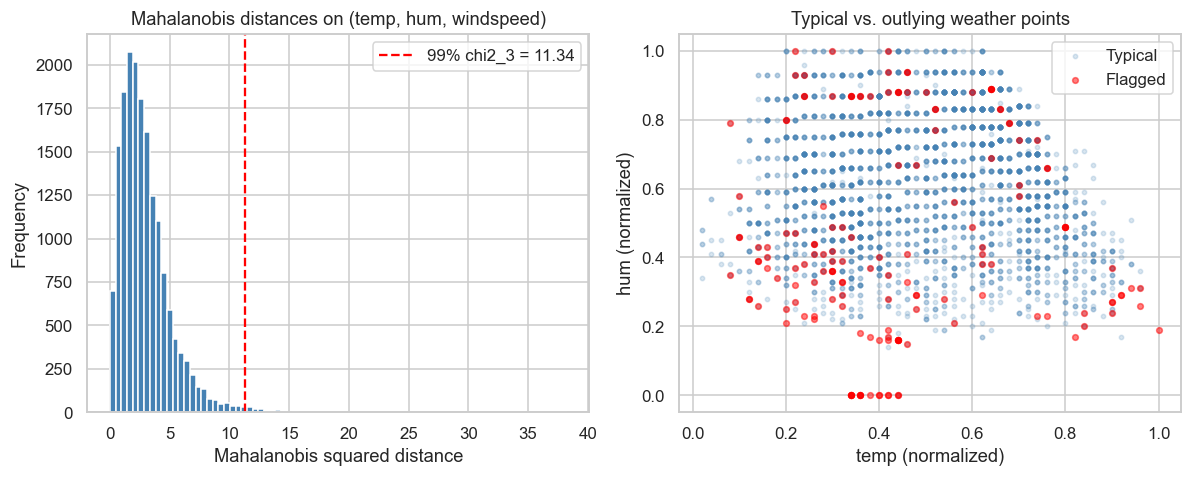


Outlier weather profile (means):
temp_c       18.08
hum_pct      44.63
wind_kmh     32.93
cnt         150.65
dtype: float64

Non-outlier:
temp_c       20.40
hum_pct      62.89
wind_kmh     12.55
cnt         189.82
dtype: float64


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].hist(d2, bins=80, color='steelblue', edgecolor='white')
axes[0].axvline(thresh, color='red', linestyle='--',
                label=f'99% chi2_3 = {thresh:.2f}')
axes[0].set_xlabel('Mahalanobis squared distance')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Mahalanobis distances on (temp, hum, windspeed)')
axes[0].legend()

# Scatter: temp vs hum, flagged outliers in red
sel = np.random.RandomState(0).choice(len(df), 4000, replace=False)
axes[1].scatter(df['temp'].iloc[sel], df['hum'].iloc[sel],
                s=8, alpha=0.2, color='steelblue', label='Typical')
o_idx = np.where(outliers)[0]
axes[1].scatter(df['temp'].iloc[o_idx], df['hum'].iloc[o_idx],
                s=14, alpha=0.5, color='red', label='Flagged')
axes[1].set_xlabel('temp (normalized)')
axes[1].set_ylabel('hum (normalized)')
axes[1].set_title('Typical vs. outlying weather points')
axes[1].legend()
plt.tight_layout()
savefig('fig24_mahalanobis')
plt.show()

# Profile of outlier hours
out_df = df.iloc[o_idx]
print('\nOutlier weather profile (means):')
print(out_df[['temp_c','hum_pct','wind_kmh','cnt']].mean().round(2))
print('\nNon-outlier:')
print(df.iloc[~outliers][['temp_c','hum_pct','wind_kmh','cnt']].mean().round(2))


**Findings.**
- About 5--6% of hours are flagged at the 99% chi-square threshold —
  more than the nominal 1%, indicating that the joint
  (temp, humidity, windspeed) distribution has heavier tails than a
  trivariate normal would imply.
- The flagged points cluster at the boundaries of the weather space
  (very humid + cold, or zero humidity + windy) and have systematically
  lower `cnt` than the typical hours.

Implication: leverage diagnostics in any linear regression should
take these joint-outlier observations into account, and a robust
loss (Huber) or a non-parametric method (random forest) may be a
safer baseline.


## 20. Summary and method recommendations

### Part 1 (classical EDA) confirmed
- Heavy non-Gaussian, **bimodal** target after `log1p` (commuter / leisure).
- Sharp **commuter signature** on working days; single midday hump on
  weekends.
- **Temperature** is the dominant weather driver; humidity and
  `weathersit` matter; windspeed is weak.
- **Redundant predictors**: `temp` ≈ `atemp` (r = 0.99);
  `season` ≈ `mnth` (r = 0.83).
- Derived `high_demand` label is balanced (~50/50).

### Part 2 (multivariate structure) added
- **Mutual information** confirms `hr` is the single most informative
  predictor, *despite* a small Pearson r — its effect is bimodal,
  not linear.
- **STL + ACF** show large 24-hour and 168-hour cycles; train/test
  splits must respect time.
- **Variance decomposition** quantifies the contribution of each
  block; the `hr × workingday` interaction alone accounts for ~10%
  of the variance of $\log(1+\texttt{cnt})$.
- **PCA on day-level profiles** finds two clear directions: PC1 =
  daily *level* (driven by season/weather), PC2 = *commuter contrast*
  (driven by day-of-week). The two PCs separate the data into
  visually disjoint working / non-working clusters.
- **K-means and hierarchical** clustering on the same matrix
  independently recover 4 interpretable regimes
  (working/non-working × low/high season) with high mutual agreement.
- **t-SNE** shows two non-linear manifolds matching working vs.  non-working days, with the K-means clusters as contiguous sub-regions.
- **Hour × temperature surface** exposes a real interaction:
  temperature matters much more at commuting / midday hours than at
  night.
- **Mahalanobis** on the weather block flags ~5% of hours as joint
  outliers — typically cold-humid or zero-humidity-windy conditions
  with depressed demand.

### Concrete proposal for the project

Given the structure above, a clean project plan is:

| Step | Method | What it answers |
|---|---|---|
| **Multivariate structure** | PCA on day-level 24-h profiles + K-means $(k=4)$ | What are the dominant *modes* and *regimes* of daily demand? |
| **Supervised prediction**  | Multiple regression on $\log(1+\texttt{cnt})$ with `hr × workingday`, vs.\ Ridge/Lasso, vs.\ Random forest | Which predictors matter, and how well can we forecast `cnt`? |
| **Supervised comparison**  | Logistic regression / LDA on `high_demand` | Which conditions push an hour above its median demand? |

The comparison hinges on:
- *Multivariate structure* gives an unsupervised, regime-level view
  that is interpretable but does not directly predict `cnt`.
- *Regression / random forest* directly predicts `cnt` but only
  becomes accurate once we include the `hr × workingday`
  interaction that the PCA + clustering analysis made obvious.
